In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 2050


In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

C:\Users\jebij\OneDrive\Desktop\ARAHFL-Medical-Federated-Learning


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from src.models import MediumCNN
from src.client import Client
from src.server import Server
from src.reliability import ReliabilityTracker

from src.utils import (
    load_pathmnist,
    partition_dirichlet,
    inject_corruption
)

print("Imports Loaded")

Imports Loaded


In [4]:
train_dataset, test_dataset = load_pathmnist()

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 89996
Test: 7180


In [5]:
client_datasets = partition_dirichlet(
    train_dataset,
    num_clients=5,
    alpha=0.5
)

print("Clients:", len(client_datasets))

Clients: 5


In [6]:
client_loaders = []

for dataset in client_datasets:

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    client_loaders.append(loader)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Loaders Ready")

Loaders Ready


In [7]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model.to(device)

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.squeeze().long().to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    return correct / total

In [8]:
def fedavg(local_weights):

    avg_weights = {}

    for key in local_weights[0]:

        avg_weights[key] = sum(
            w[key]
            for w in local_weights
        ) / len(local_weights)

    return avg_weights

In [9]:
global_model = MediumCNN(
    num_classes=9
)

print("Baseline Model Ready")

Baseline Model Ready


In [10]:
baseline_clients = []

for loader in client_loaders:

    model = MediumCNN(
        num_classes=9
    )

    model.load_state_dict(
        global_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    baseline_clients.append(client)

print(
    "Baseline Clients:",
    len(baseline_clients)
)

Baseline Clients: 5


In [11]:
baseline_accuracy = []

ROUNDS = 20

for rnd in range(ROUNDS):

    print(
        f"\n===== BASELINE ROUND {rnd+1} ====="
    )

    local_weights = []

    for client in baseline_clients:

        loss, reliability = client.train(
            epochs=1
        )

        local_weights.append(
            client.get_weights()
        )

    global_weights = fedavg(
        local_weights
    )

    global_model.load_state_dict(
        global_weights
    )

    for client in baseline_clients:

        client.set_weights(
            global_weights
        )

    acc = evaluate(
        global_model,
        test_loader
    )

    baseline_accuracy.append(acc)

    print(
        f"Accuracy = {acc:.4f}"
    )


===== BASELINE ROUND 1 =====
Accuracy = 0.4695

===== BASELINE ROUND 2 =====
Accuracy = 0.5818

===== BASELINE ROUND 3 =====
Accuracy = 0.7368

===== BASELINE ROUND 4 =====
Accuracy = 0.6852

===== BASELINE ROUND 5 =====
Accuracy = 0.7787

===== BASELINE ROUND 6 =====
Accuracy = 0.7975

===== BASELINE ROUND 7 =====
Accuracy = 0.8024

===== BASELINE ROUND 8 =====
Accuracy = 0.8221

===== BASELINE ROUND 9 =====
Accuracy = 0.8263

===== BASELINE ROUND 10 =====
Accuracy = 0.7251

===== BASELINE ROUND 11 =====
Accuracy = 0.8203

===== BASELINE ROUND 12 =====
Accuracy = 0.7694

===== BASELINE ROUND 13 =====
Accuracy = 0.8028

===== BASELINE ROUND 14 =====
Accuracy = 0.8409

===== BASELINE ROUND 15 =====
Accuracy = 0.8699

===== BASELINE ROUND 16 =====
Accuracy = 0.8575

===== BASELINE ROUND 17 =====
Accuracy = 0.8269

===== BASELINE ROUND 18 =====
Accuracy = 0.8607

===== BASELINE ROUND 19 =====
Accuracy = 0.8486

===== BASELINE ROUND 20 =====
Accuracy = 0.8705


In [12]:
arahfl_model = MediumCNN(
    num_classes=9
)

tracker = ReliabilityTracker()

server = Server(
    global_model=arahfl_model,
    reliability_tracker=tracker
)

print("ARAHFL Ready")

ARAHFL Ready


In [13]:
arahfl_clients = []

for loader in client_loaders:

    model = MediumCNN(
        num_classes=9
    )

    model.load_state_dict(
        arahfl_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    arahfl_clients.append(client)

print(
    "ARAHFL Clients:",
    len(arahfl_clients)
)

ARAHFL Clients: 5


In [14]:
CORRUPTED_CLIENTS = [1, 3]

print(
    "Corrupted Clients:",
    CORRUPTED_CLIENTS
)

Corrupted Clients: [1, 3]


In [18]:
arahfl_accuracy = []

ROUNDS = 20

for rnd in range(ROUNDS):

    print(f"\n===== ARAHFL ROUND {rnd+1} =====")

    server.client_updates = []
    server.client_ids = []

    noise_level = min(
        0.005 + rnd * 0.001,
        0.02
    )

    print(f"Noise Level = {noise_level:.3f}")

    for client_id, client in enumerate(arahfl_clients):

        original_loader = client.train_loader

        # Corrupt Client 1 and Client 3
        if client_id in [1, 3]:

            corrupted_batches = []

            for images, labels in original_loader:

                corrupted_images = inject_corruption(
                    images,
                    noise_level=noise_level
                )

                corrupted_batches.append(
                    (
                        corrupted_images,
                        labels
                    )
                )

            client.train_loader = corrupted_batches

        # Train client
        loss, _ = client.train(
            epochs=1
        )

        reliability = tracker.compute_reliability(
            client_id,
            loss
        )

        server.add_client_update(
            client_id,
            client.get_weights()
        )

        print(
            f"Client {client_id} | "
            f"Loss={loss:.4f} | "
            f"Reliability={reliability:.4f}"
        )

        # Restore original loader
        if client_id in [1, 3]:
            client.train_loader = original_loader

    # Aggregate
    global_weights = server.aggregate()

    arahfl_model.load_state_dict(
        global_weights
    )

    # Send global model back to clients
    for client in arahfl_clients:

        client.set_weights(
            global_weights
        )

    # Evaluate
    acc = evaluate(
        arahfl_model,
        test_loader
    )

    arahfl_accuracy.append(acc)

    server.log_global_accuracy(acc)

    print(
        f"Global Accuracy={acc:.4f}"
    )


===== ARAHFL ROUND 1 =====
Noise Level = 0.005
Client 0 | Loss=0.6180 | Reliability=1.0000
Client 1 | Loss=0.9807 | Reliability=0.9206
Client 2 | Loss=0.7507 | Reliability=1.0000
Client 3 | Loss=0.8777 | Reliability=1.0000
Client 4 | Loss=0.8971 | Reliability=0.9800
Global Accuracy=0.7230

===== ARAHFL ROUND 2 =====
Noise Level = 0.006
Client 0 | Loss=0.6009 | Reliability=1.0000
Client 1 | Loss=0.9274 | Reliability=0.9756
Client 2 | Loss=0.7029 | Reliability=1.0000
Client 3 | Loss=0.9045 | Reliability=1.0000
Client 4 | Loss=0.8018 | Reliability=1.0000
Global Accuracy=0.7432

===== ARAHFL ROUND 3 =====
Noise Level = 0.007
Client 0 | Loss=0.6064 | Reliability=1.0000
Client 1 | Loss=0.9329 | Reliability=1.0000
Client 2 | Loss=0.6771 | Reliability=1.0000
Client 3 | Loss=0.7759 | Reliability=1.0000
Client 4 | Loss=0.7841 | Reliability=1.0000
Global Accuracy=0.7549

===== ARAHFL ROUND 4 =====
Noise Level = 0.008
Client 0 | Loss=0.5387 | Reliability=1.0000
Client 1 | Loss=0.8794 | Reliabilit

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000025328CDD080>
Traceback (most recent call last):
  File "C:\Users\jebij\OneDrive\Desktop\ARAHFL-Medical-Federated-Learning\arahfl_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\jebij\OneDrive\Desktop\ARAHFL-Medical-Federated-Learning\arahfl_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Client 0 | Loss=0.5114 | Reliability=1.0000
Client 1 | Loss=0.8425 | Reliability=1.0000
Client 2 | Loss=0.6709 | Reliability=1.0000
Client 3 | Loss=0.7300 | Reliability=1.0000
Client 4 | Loss=0.7174 | Reliability=1.0000
Global Accuracy=0.7487

===== ARAHFL ROUND 8 =====
Noise Level = 0.012
Client 0 | Loss=0.5526 | Reliability=1.0000
Client 1 | Loss=0.8100 | Reliability=1.0000
Client 2 | Loss=0.6488 | Reliability=1.0000
Client 3 | Loss=0.6529 | Reliability=1.0000
Client 4 | Loss=0.7415 | Reliability=1.0000
Global Accuracy=0.8043

===== ARAHFL ROUND 9 =====
Noise Level = 0.013
Client 0 | Loss=0.5593 | Reliability=1.0000
Client 1 | Loss=0.8115 | Reliability=1.0000
Client 2 | Loss=0.6367 | Reliability=1.0000
Client 3 | Loss=0.6838 | Reliability=1.0000
Client 4 | Loss=0.7404 | Reliability=1.0000
Global Accuracy=0.8326

===== ARAHFL ROUND 10 =====
Noise Level = 0.014
Client 0 | Loss=0.5715 | Reliability=1.0000
Client 1 | Loss=0.8377 | Reliability=1.0000
Client 2 | Loss=0.6522 | Reliability=1

In [19]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["FedAvg", "ARAHFL"],
    "Final Accuracy": [
        baseline_accuracy[-1],
        arahfl_accuracy[-1]
    ]
})

results

,Method,Final Accuracy
0,FedAvg,0.870474
1,ARAHFL,0.844986


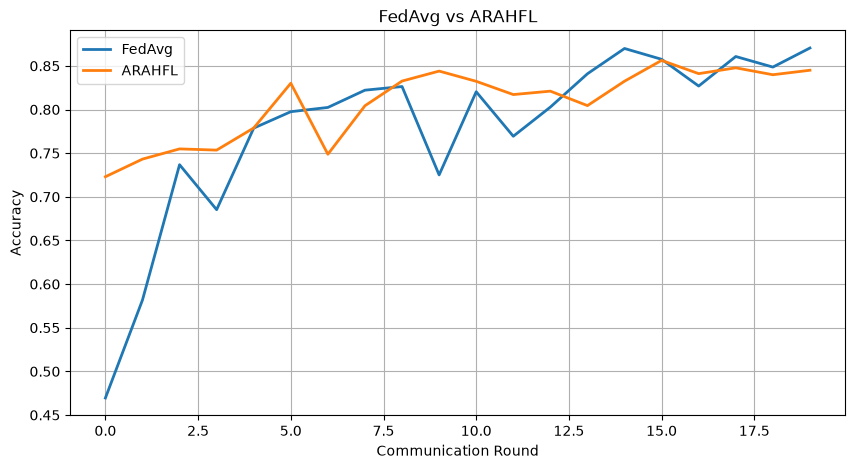

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    baseline_accuracy,
    label="FedAvg",
    linewidth=2
)

plt.plot(
    arahfl_accuracy,
    label="ARAHFL",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("FedAvg vs ARAHFL")

plt.legend()
plt.grid(True)

plt.show()

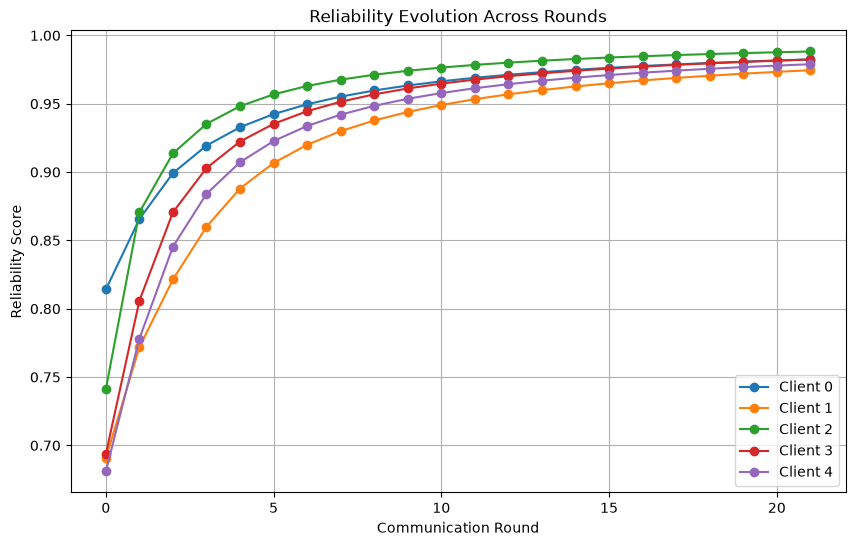

In [21]:
import matplotlib.pyplot as plt
import numpy as np

reliability_history = np.array(
    server.get_reliability_history()
)

plt.figure(figsize=(10,6))

for client_id in range(
    reliability_history.shape[1]
):
    plt.plot(
        reliability_history[:, client_id],
        marker='o',
        label=f'Client {client_id}'
    )

plt.title(
    "Reliability Evolution Across Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Reliability Score"
)

plt.grid(True)

plt.legend()

plt.show()

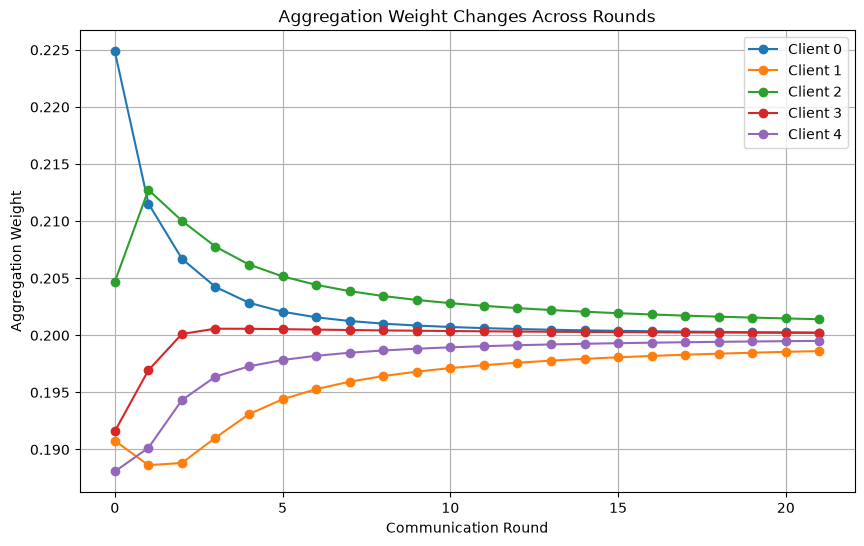

In [22]:
import matplotlib.pyplot as plt
import numpy as np

weight_history = np.array(
    server.get_weight_history()
)

plt.figure(figsize=(10,6))

for client_id in range(
    weight_history.shape[1]
):
    plt.plot(
        weight_history[:, client_id],
        marker='o',
        label=f'Client {client_id}'
    )

plt.title(
    "Aggregation Weight Changes Across Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Aggregation Weight"
)

plt.grid(True)

plt.legend()

plt.show()